<a href="https://colab.research.google.com/github/akashamala2007-beep/AKASH/blob/main/E-commerce.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Step 1: Generating Messy Dataset ---
Initial Dataset Shape (with messiness): (1125, 4)

First 5 rows of raw dataset:
        Date     Product  Quantity  Price_Per_Unit
0 2025-01-01  Smartwatch       1.0             300
1 2025-01-01      Tablet       1.0             500
2 2025-01-01  Headphones       1.0             500
3 2025-01-02      Tablet       1.0              50
4 2025-01-02      Tablet       2.0             300
--------------------------------------------------

--- Step 2: Data Cleaning ---
Identified duplicates: 52
Dataset shape after removing duplicates: (1073, 4)

Missing values per column before cleaning:
Date               0
Product            0
Quantity          55
Price_Per_Unit     0
dtype: int64

Filled missing 'Quantity' values with median: 1.0
Missing values remaining in 'Quantity': 0

First 5 rows of Cleaned Dataset:
        Date     Product  Quantity  Price_Per_Unit  Revenue
0 2025-01-01  Smartwatch       1.0             300    300.0
1 2025-01-01      Tablet  

/tmp/ipykernel_6992/3958254811.py:58: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df["Quantity"].fillna(quantity_median, inplace=True)


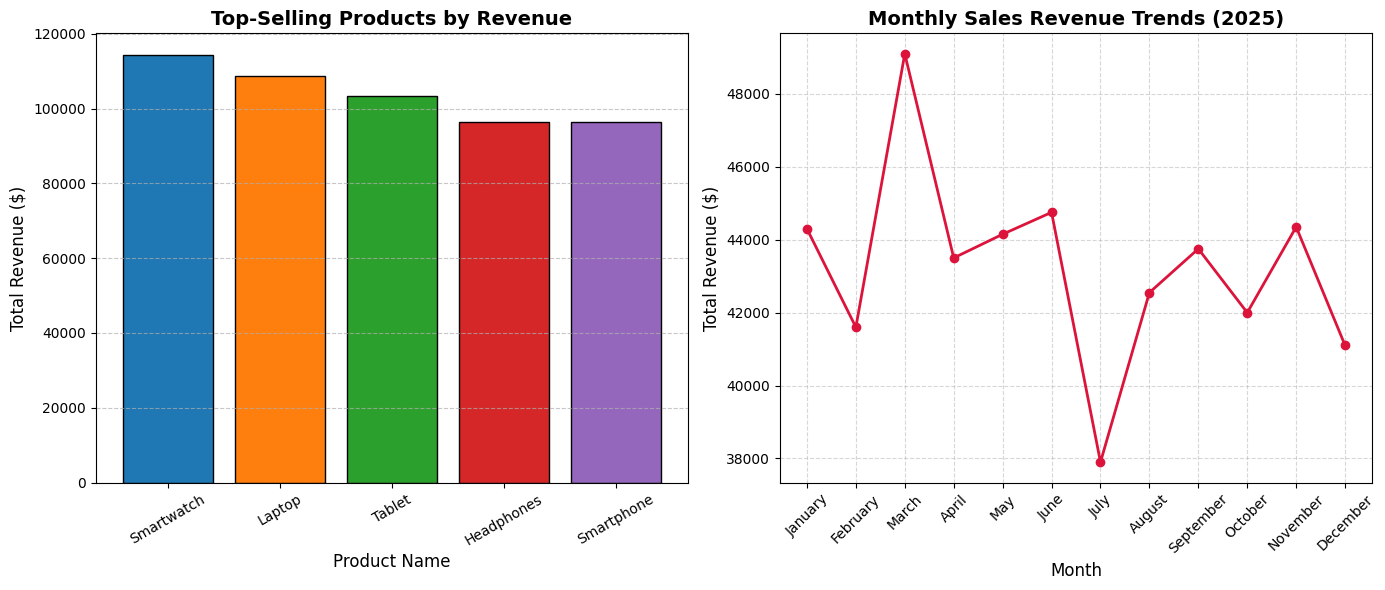

In [1]:
# ==============================================================================
# NAAN MUDHALVAN ARTS INTERNSHIP PROGRAM 2026
# Project: E-Commerce Sales Performance Analysis
# Tools Covered: Pandas, NumPy, Matplotlib
# ==============================================================================

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ------------------------------------------------------------------------------
# STEP 1: DATASET GENERATION (Simulating a Messy Sales Dataset)
# ------------------------------------------------------------------------------
print("--- Step 1: Generating Messy Dataset ---")
np.random.seed(42)

# Creating mock data
dates = pd.date_range(start="2025-01-01", end="2025-12-31", freq="D").repeat(3)
products = ["Laptop", "Smartphone", "Headphones", "Smartwatch", "Tablet"]

data = {
    "Date": dates,
    "Product": np.random.choice(products, size=len(dates)),
    "Quantity": np.random.choice([1, 2, 3, np.nan, 4], size=len(dates), p=[0.7, 0.15, 0.08, 0.05, 0.02]),
    "Price_Per_Unit": np.random.choice([800, 500, 50, 150, 300], size=len(dates))
}

df_messy = pd.DataFrame(data)

# Injecting duplicate rows to simulate messy real-world data
duplicates = df_messy.sample(n=30, random_state=42)
df = pd.concat([df_messy, duplicates], ignore_index=True)

print(f"Initial Dataset Shape (with messiness): {df.shape}")
print("\nFirst 5 rows of raw dataset:")
print(df.head())
print("-" * 50)


# ------------------------------------------------------------------------------
# STEP 2: DATA CLEANING (Handling Missing Values & Duplicates)
# ------------------------------------------------------------------------------
print("\n--- Step 2: Data Cleaning ---")

# 1. Check for duplicates and drop them
duplicate_count = df.duplicated().sum()
print(f"Identified duplicates: {duplicate_count}")
df.drop_duplicates(inplace=True)
print(f"Dataset shape after removing duplicates: {df.shape}")

# 2. Check for missing values
missing_values = df.isnull().sum()
print("\nMissing values per column before cleaning:")
print(missing_values)

# Handle missing values in 'Quantity' by filling them with the median value
quantity_median = df["Quantity"].median()
df["Quantity"].fillna(quantity_median, inplace=True)
print(f"\nFilled missing 'Quantity' values with median: {quantity_median}")
print(f"Missing values remaining in 'Quantity': {df['Quantity'].isnull().sum()}")

# 3. Add Calculated Column: Revenue
df["Revenue"] = df["Quantity"] * df["Price_Per_Unit"]

print("\nFirst 5 rows of Cleaned Dataset:")
print(df.head())
print("-" * 50)


# ------------------------------------------------------------------------------
# STEP 3: DATA ANALYSIS
# ------------------------------------------------------------------------------
print("\n--- Step 3: Data Analysis ---")

# Task 3.1: Analyze Top-Selling Products (By Revenue)
product_performance = df.groupby("Product").agg(
    Units_Sold=("Quantity", "sum"),
    Total_Revenue=("Revenue", "sum")
).sort_values(by="Total_Revenue", ascending=False)

print("\n[Top-Selling Products Summary]")
print(product_performance)

# Task 3.2: Identify Monthly Sales Trends
df["Month"] = df["Date"].dt.strftime("%m-%B") # Extract Month Number and Name
monthly_trends = df.groupby("Month").agg(
    Total_Revenue=("Revenue", "sum")
).sort_index()

print("\n[Monthly Revenue Trends]")
print(monthly_trends)
print("-" * 50)


# ------------------------------------------------------------------------------
# STEP 4: DATA VISUALIZATION
# ------------------------------------------------------------------------------
print("\n--- Step 4: Generating Visualizations ---")

# Setup plot style and figure size
plt.figure(figsize=(14, 6))

# Plot 1: Bar Chart for Top-Selling Products (Revenue)
plt.subplot(1, 2, 1)
colors = ["#1f77b4", "#ff7f0e", "#2ca02c", "#d62728", "#9467bd"]
plt.bar(product_performance.index, product_performance["Total_Revenue"], color=colors, edgecolor='black')
plt.title("Top-Selling Products by Revenue", fontsize=14, fontweight='bold')
plt.xlabel("Product Name", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.xticks(rotation=30)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Plot 2: Line Chart for Monthly Sales Trends
plt.subplot(1, 2, 2)
# Extract just the month names for cleaner X-axis labels
clean_month_labels = [m.split("-")[1] for m in monthly_trends.index]
plt.plot(clean_month_labels, monthly_trends["Total_Revenue"], marker='o', color='crimson', linewidth=2, linestyle='-')
plt.title("Monthly Sales Revenue Trends (2025)", fontsize=14, fontweight='bold')
plt.xlabel("Month", fontsize=12)
plt.ylabel("Total Revenue ($)", fontsize=12)
plt.xticks(rotation=45)
plt.grid(True, linestyle='--', alpha=0.5)

# Adjust layout and show the charts
plt.tight_layout()
plt.show()